<a href="https://colab.research.google.com/github/SANIKA0308/AIML_project/blob/main/AIML_projectFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Industrial Motor Acoustic Diagnostic System
**Predictive Maintenance Dashboard (v2.0)**

This system provides real-time motor health analysis using Acoustic Emission (AE) monitoring and Deep Convolutional Neural Networks.

## 1. Environment Setup & Data Acquisition

In [16]:
import os
import sys
import glob
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import display, Audio, HTML
import warnings
from sklearn.metrics import confusion_matrix
from google.colab import files

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
warnings.filterwarnings("ignore")

# Configuration Constants
FRAME_LENGTH, FRAME_STEP = 255, 128
BATCH_SIZE = 32
SEQ_LEN = 16000
TRAIN_DATASET = './IDMT-ISA-ELECTRIC-ENGINE/train_cut'
VALID_DATASET = './IDMT-ISA-ELECTRIC-ENGINE/test_cut'

# Dataset Acquisition Logic
if not os.path.exists('./IDMT-ISA-ELECTRIC-ENGINE'):
    print("Initializing Acoustic Database...")
    try:
        from google.colab import userdata
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    except:
        os.environ['KAGGLE_USERNAME'] = input('Kaggle Username: ')
        os.environ['KAGGLE_KEY'] = input('Kaggle Key: ')

    !pip install --upgrade kaggle -q
    !kaggle datasets download pythonafroz/electrical-motor-operational-state-sound-data --unzip
    print("\nDatabase Link Established Successfully.")
else:
    print("Local Database Found. Ready for Processing.")

Local Database Found. Ready for Processing.


## 2. Acoustic Feature Engineering Engine

In [17]:
class DiagnosticProcessor():
    def __init__(self): pass

    def get_rms(self, wf):
        """Extracts Root Mean Square (Vibration Intensity)."""
        return np.sqrt(np.mean(wf**2))

    def get_zcr(self, wf):
        """Extracts Zero Crossing Rate (Friction/Bearing noise indicator)."""
        return len(np.where(np.diff(np.sign(wf)))[0]) / len(wf)

    def get_spectrogram(self, wf):
        """Generates a 3-channel Spectrogram [Spec, Delta, Delta-Delta]."""
        spec = tf.abs(tf.signal.stft(wf, frame_length=FRAME_LENGTH, frame_step=FRAME_STEP))
        def compute_delta(t):
            delta = t[..., 1:, :] - t[..., :-1, :]
            return tf.concat([tf.zeros_like(t[..., :1, :]), delta], axis=-2)

        d1 = compute_delta(spec)
        d2 = compute_delta(d1)
        return tf.stack([spec, d1, d2], axis=-1)

def get_ds():
    """Initializes data pipelines from directory."""
    tr = tf.keras.utils.audio_dataset_from_directory(TRAIN_DATASET, batch_size=BATCH_SIZE, output_sequence_length=SEQ_LEN, seed=seed)
    te = tf.keras.utils.audio_dataset_from_directory(VALID_DATASET, batch_size=BATCH_SIZE, output_sequence_length=SEQ_LEN, seed=seed)
    sq = lambda x, y: (tf.squeeze(x, axis=-1), y)
    return tr.map(sq), te.map(sq).shard(2,0), te.map(sq).shard(2,1), tr.class_names

proc = DiagnosticProcessor()
train_ds, val_ds, test_ds, classes = get_ds()

def prep(ds):
    return ds.map(lambda x, y: (proc.get_spectrogram(x), y)).cache().prefetch(tf.data.AUTOTUNE)

train_spec, val_spec = prep(train_ds), prep(val_ds)
print(f"Target Maintenance States: {classes}")

Found 357 files belonging to 3 classes.
Found 2021 files belonging to 3 classes.
Target Maintenance States: ['engine1_good', 'engine2_broken', 'engine3_heavyload']


## 3. Model Architecture & Neural Training

In [18]:
# Determine Input Shape
for example_spec, _ in train_spec.take(1):
    input_shape = example_spec.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    layers.Normalization(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes))
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Starting Neural Training Pipeline...")
history = model.fit(train_spec, validation_data=val_spec, epochs=10)

Starting Neural Training Pipeline...
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 884ms/step - accuracy: 0.9132 - loss: 0.2225 - val_accuracy: 0.9570 - val_loss: 0.5091
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 1.0000 - loss: 1.6126e-04 - val_accuracy: 0.9521 - val_loss: 0.8224
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 1.0000 - loss: 1.5190e-05 - val_accuracy: 0.9512 - val_loss: 0.9788
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 1.0000 - loss: 3.4660e-07 - val_accuracy: 0.9512 - val_loss: 1.0363
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 1.0000 - loss: 9.6957e-06 - val_accuracy: 0.9512 - val_loss: 1.0637
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - accuracy: 1.0000 - loss: 9.9031e-06 - val_accuracy: 0.9512 - val_loss: 1.0800
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 1.0000 - loss: 2.2581e-06 - val_accuracy: 0.9512 - val_loss: 1.0959
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 2

## 4. Professional Diagnostic Dashboard Reporting

In [19]:
def run_ai_dashboard(file_path):
    """Generates a formatted report for a given audio file."""
    try:
        wf, _ = tf.audio.decode_wav(tf.io.read_file(file_path), desired_channels=1, desired_samples=SEQ_LEN)
    except:
        print(f"Error: File {file_path} is not a valid WAV file."); return

    wf = tf.squeeze(wf, axis=-1).numpy()
    rms, zcr = proc.get_rms(wf), proc.get_zcr(wf)

    # Get Model Prediction
    pred = model.predict(proc.get_spectrogram(wf)[tf.newaxis,...], verbose=0)
    idx = np.argmax(pred[0])
    conf = tf.nn.softmax(pred[0])[idx] * 100
    state = classes[idx].upper()

    # Dashboard Visualization Config
    color = "#28a745" if "GOOD" in state else "#ffc107" if "LOAD" in state else "#dc3545"
    status_text = "OPTIMAL OPERATION" if "GOOD" in state else "HEAVY LOAD" if "LOAD" in state else "CRITICAL SYSTEM FAILURE"

    # Professional HTML Dashboard
    html_report = f"""
    <div style="border-left: 10px solid {color}; padding: 20px; border-radius: 5px; background-color: #f1f3f5; font-family: 'Segoe UI', sans-serif;">
        <h3 style="color: {color}; margin: 0; text-transform: uppercase;">Diagnostic Status: {status_text}</h3>
        <hr style="border: 0.5px solid #ccc;">
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
            <div>
                <p><b>Predicted Maintenance State:</b> {state}</p>
                <p><b>AI Classification Confidence:</b> {conf:.2f}%</p>
                <p><b>Analysis Target:</b> {os.path.basename(file_path)}</p>
            </div>
            <div style="border-left: 2px dashed #adb5bd; padding-left: 20px;">
                <p><b>Vibration Intensity (RMS):</b> <span style="font-family: monospace;">{rms:.4f}</span></p>
                <p><b>Friction Index (ZCR):</b> <span style="font-family: monospace;">{zcr:.4f}</span></p>
                <p><b>Maintenance Recommendation:</b> <span style="color: {color}; font-weight: bold;">{'NONE' if 'GOOD' in state else 'SCHEDULE INSPECTION'}</span></p>
            </div>
        </div>
    </div>
    """
    display(HTML(html_report))

    # Signal Analysis Plots
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 2, 1); plt.plot(wf, color=color, alpha=0.7); plt.title("Acoustic Waveform (Time Domain)"); plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2); spec_data = proc.get_spectrogram(wf).numpy()[..., 0]; plt.pcolormesh(np.log(spec_data.T + 1e-6), cmap='viridis'); plt.title("Acoustic Signature (Spectrogram)")
    plt.tight_layout(); plt.show()
    display(Audio(wf, rate=16000))

## 5. Interactive Inspection Interface

UPLOAD MOTOR RECORDING (.WAV) FOR DIAGNOSTIC:


Saving freesound_community-electric-motor-engine-start-stop-98304.wav to freesound_community-electric-motor-engine-start-stop-98304.wav

Initiating diagnosis for "freesound_community-electric-motor-engine-start-stop-98304.wav"...


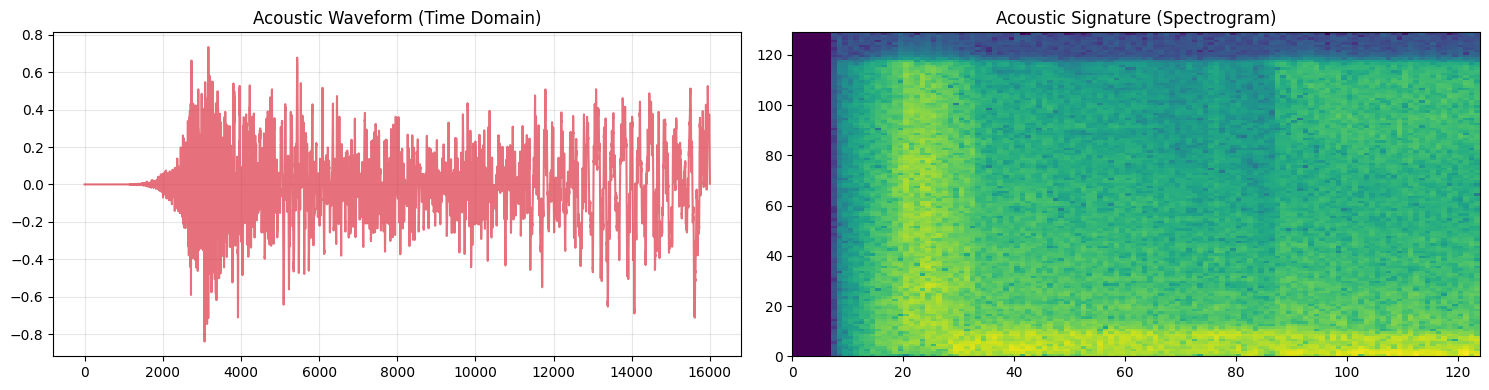

In [28]:
print("UPLOAD MOTOR RECORDING (.WAV) FOR DIAGNOSTIC:")
uploaded_files = files.upload()

for filename in uploaded_files.keys():
    print(f'\nInitiating diagnosis for "{filename}"...')
    run_ai_dashboard(filename)

## 6. System Validation (Samples)

Running Validation on Known Samples...


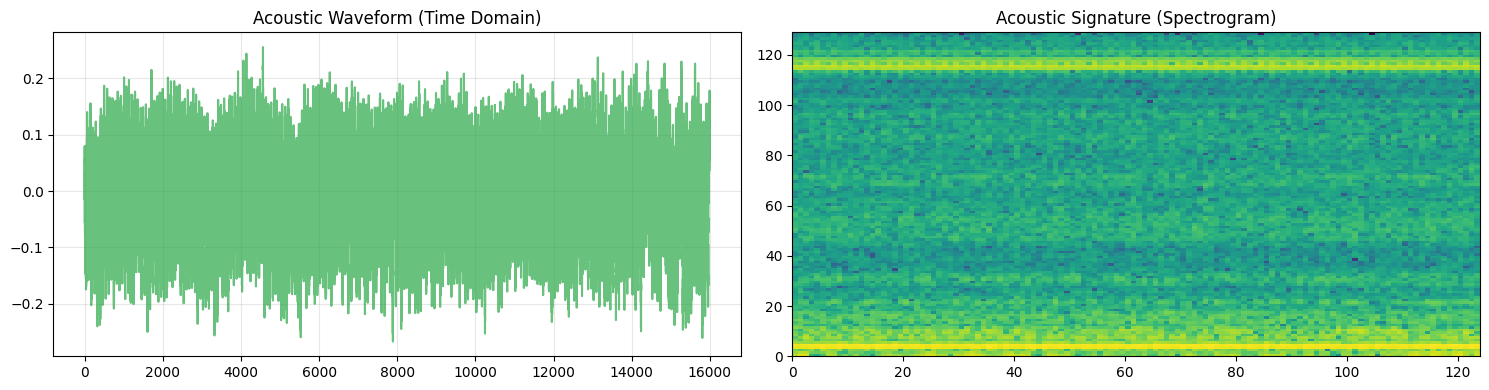

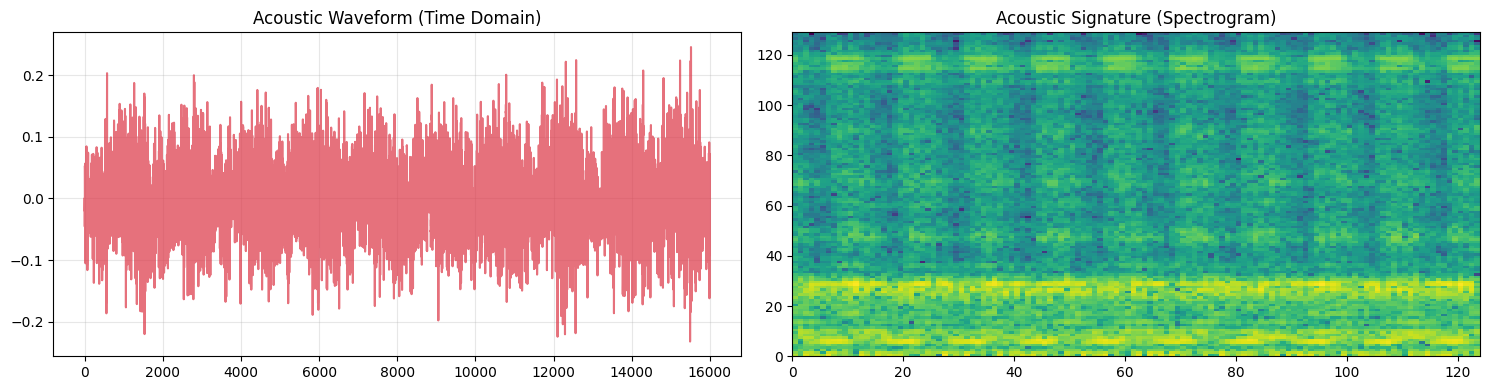

In [21]:
print("Running Validation on Known Samples...")
samples = ['./IDMT-ISA-ELECTRIC-ENGINE/train_cut/engine1_good/pure_1.wav',
           './IDMT-ISA-ELECTRIC-ENGINE/train_cut/engine2_broken/pure_10.wav']

for s in samples:
    if os.path.exists(s): run_ai_dashboard(s)